imports and dataset loading part


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import ta

import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("../data/raw/AMZN.csv")

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


missing values converting dates


In [14]:
df.isnull().sum()
df["Date"] = pd.to_datetime(df["Date"])

df.head()
df.set_index("Date", inplace=True)

techinical indicators part sma 20,50 ema 20,rsi and macd


In [15]:
df["SMA_20"] = ta.trend.sma_indicator(
    close=df["Close"],
    window=20
)
df["SMA_50"] = ta.trend.sma_indicator(
    close=df["Close"],
    window=50
)
df["EMA_20"] = ta.trend.ema_indicator(
    close=df["Close"],
    window=20
)
df["RSI"] = ta.momentum.rsi(
    close=df["Close"],
    window=14
)
macd = ta.trend.MACD(close=df["Close"])

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()

view dataset and Visualization part rsi and macd plot


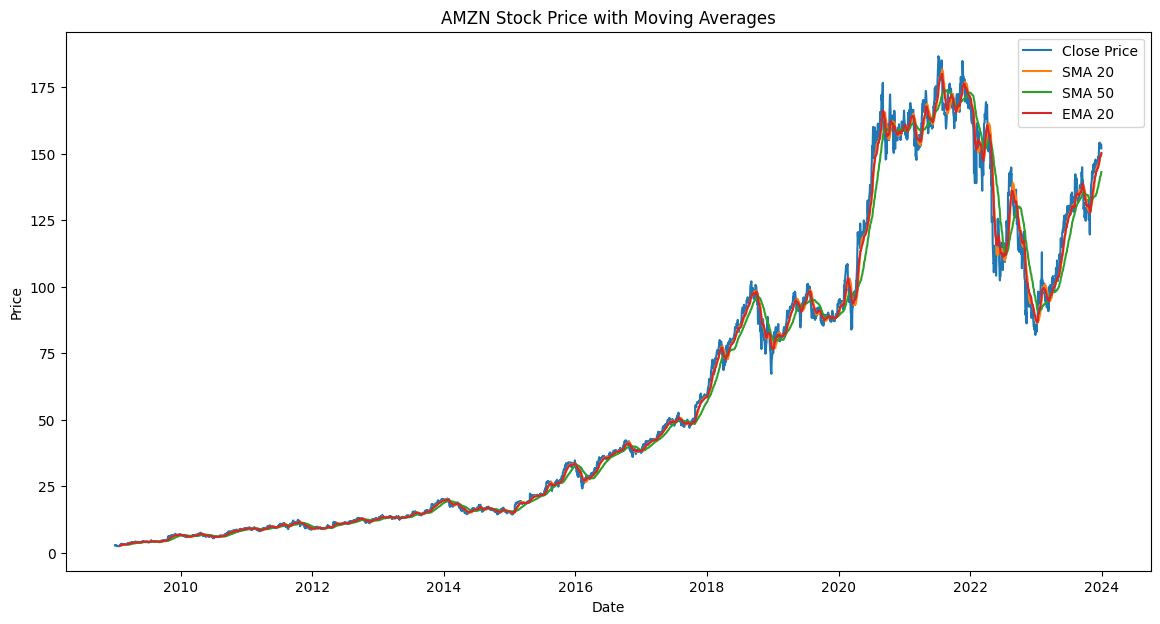

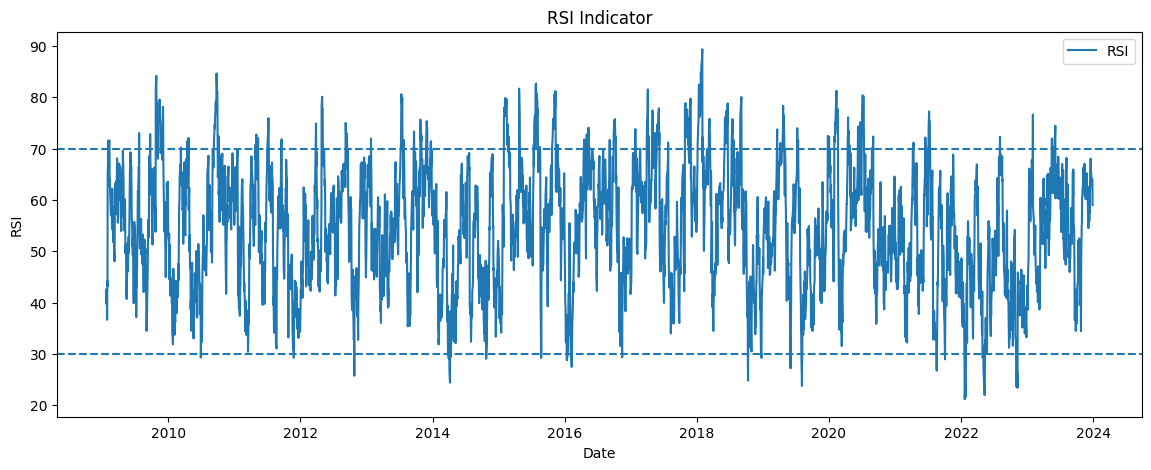

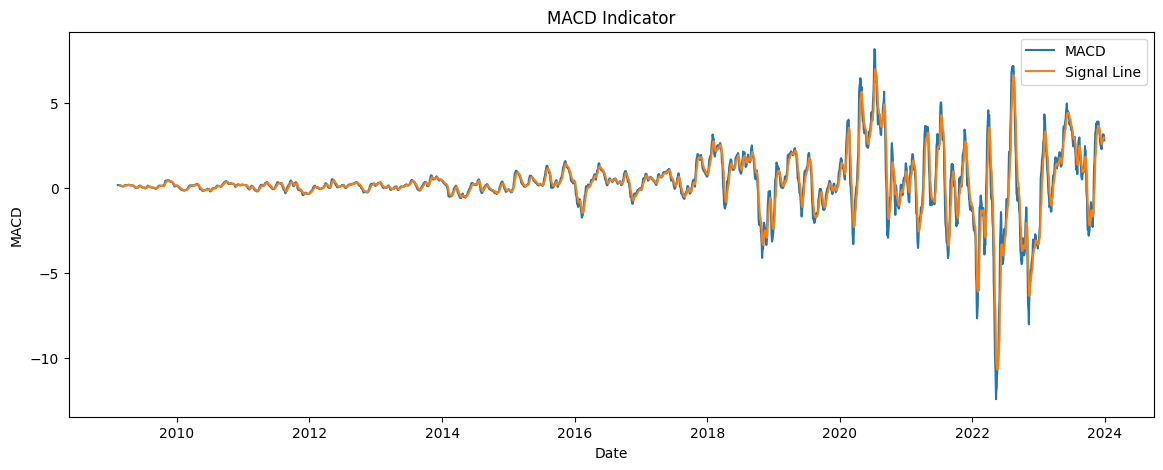

In [16]:
df.head(30)
plt.figure(figsize=(14, 7))

plt.plot(df.index, df["Close"], label="Close Price")
plt.plot(df.index, df["SMA_20"], label="SMA 20")
plt.plot(df.index, df["SMA_50"], label="SMA 50")
plt.plot(df.index, df["EMA_20"], label="EMA 20")

plt.title("AMZN Stock Price with Moving Averages")

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()
plt.figure(figsize=(14, 5))

plt.plot(df.index, df["RSI"], label="RSI")

plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")

plt.title("RSI Indicator")

plt.xlabel("Date")
plt.ylabel("RSI")

plt.legend()

plt.show()
plt.figure(figsize=(14, 5))

plt.plot(df.index, df["MACD"], label="MACD")
plt.plot(df.index, df["MACD_SIGNAL"], label="Signal Line")

plt.title("MACD Indicator")

plt.xlabel("Date")
plt.ylabel("MACD")

plt.legend()

plt.show()

daily return part


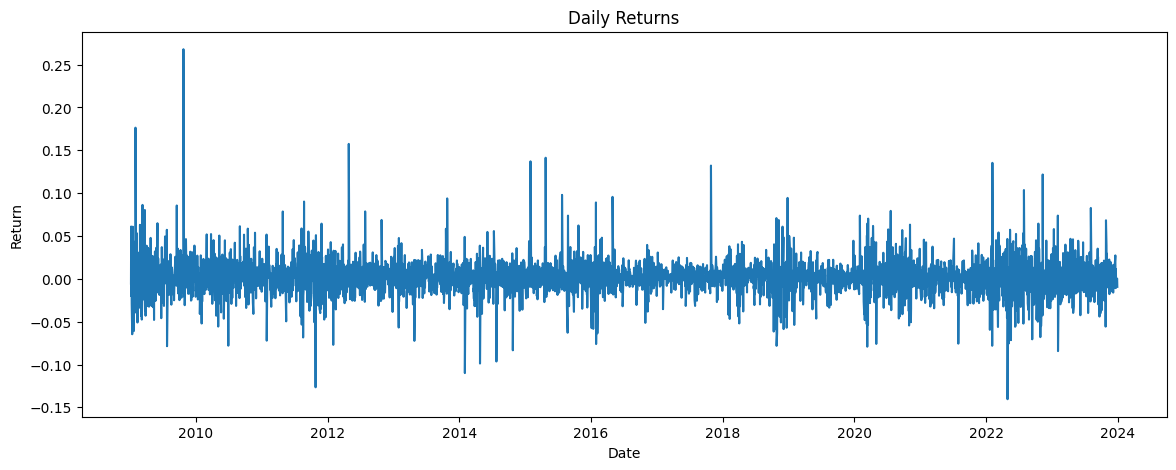

In [17]:
df["Daily_Return"] = df["Close"].pct_change()

df["Daily_Return"].head()
plt.figure(figsize=(14, 5))

plt.plot(df.index, df["Daily_Return"])

plt.title("Daily Returns")

plt.xlabel("Date")
plt.ylabel("Return")

plt.show()

corelation matrix part


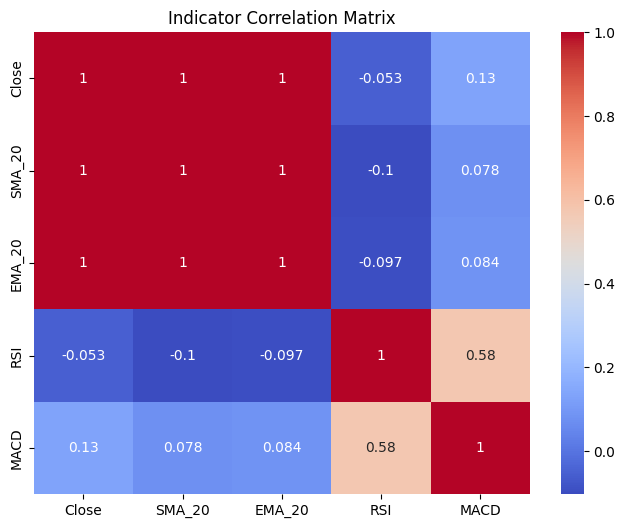

In [18]:
correlation = df[
    ["Close", "SMA_20", "EMA_20", "RSI", "MACD"]
].corr()

correlation
plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Indicator Correlation Matrix")

plt.show()

 Key Insights

1. Moving averages reveal long-term trend direction and smooth market volatility.
2. RSI highlights periods of overbought and oversold market conditions.
3. MACD captures momentum shifts and possible trend reversals.
4. Daily return volatility indicates periods of significant market activity.
5. Technical indicators provide quantitative signals that can later be combined with sentiment analysis for predictive modeling.